In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
import pickle

In [2]:
class Dataset_converter(Dataset):
    def __init__(self, data, token_size, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), token_size), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, token_size*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), token_size))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*token_size:(kk+1)*token_size] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [3]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers=2, num_layers_sleep=2, output_size=7):
        super(brain, self).__init__()

        self.sleep_output_size = sleep_output_size
        self.rnn = nn.RNN(input_size+sleep_output_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(input_size, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, sleep_output_size)
        self.wake_fc = nn.Linear(hidden_wake_size, output_size)

    def forward(self, x, x_=None, hw=None, hs=None, sleep=False, short_term_memory=1, working_memory=1):
        # print(x.shape, 'x')
        if sleep:
            if hs == None:
                out, hs = self.sleep_rnn(x_)
            else:
                out, hs = self.sleep_rnn(x_, hs)
            # print(out.shape)
            sleep_out = self.sleep_fc(out)
        else:
            sleep_out = torch.zeros((1,short_term_memory,self.sleep_output_size))
            
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out[:,-1,:])

        if sleep:
            return out, hw, hs
        else:
            return out, hw


In [4]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, token_size=7):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, token_size)
        
    def forward(self, x, hw=None, short_term_memory=None):
        if hw is None:
            out, hw = self.rnn(x)
        else:   
            out, hw = self.rnn(x, hw)
            
        out = self.fc1(out[:,-1,:])
        return out, hw


In [5]:
def wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=4e-4):
    data_set = Dataset_converter(train_data, token_size, working_memory, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)
    data_set = Dataset_converter(test_data, token_size, working_memory, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()

    total = 0
    correct_train = np.zeros(1000,dtype=float)
    correct_test = np.zeros(1000,dtype=float)
    train_acc = []
    test_acc = []
    for (X_train, y_train), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = model(X_train, short_term_memory=short_term_memory)
        else:
            predicted_y, hidden = model(X_train, hw=memory, short_term_memory=short_term_memory)

        #print(predicted_y.shape, y_train.shape)
        loss = criterion(predicted_y, y_train)
        loss.backward(retain_graph=True)
        optimizer.step()

        with torch.no_grad():
            memory = hidden.clone()
            true_y = y_train.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)

            if total == 0:
                predicted_y_test, hidden_ = model(X_test, short_term_memory=short_term_memory)
            else:
                predicted_y_test, hidden_ = model(X_test, hw=hidden_, short_term_memory=short_term_memory)

            true_y_test = y_test.argmax(axis=1)
            estimated_y_test = predicted_y_test.argmax(axis=1)

            total += 1
            if true_y == estimated_y:
                correct_train[total%1000] = 1
            else:
                correct_train[total%1000] = 0


            if true_y_test == estimated_y_test:
                correct_test[total%1000] = 1
            else:
                correct_test[total%1000] = 0


            train_acc.append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            test_acc.append(
                np.sum(correct_test)/total if total<1000 else np.sum(correct_test)/1000
            )

            # if total%1000 == 0:
            #     print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[-1]:.4f}, test accuracy: {test_acc[-1]:.4f}')

    return model, train_acc, test_acc

In [20]:
nodes = [10,100,500,1000]
layers = [1,2,3,4,5,6,7,8,9,10]
reps = 5
lr = 4e-4
result_train = {}
result_test = {}

total_samples = 50000
working_memory = 1
short_term_memory = 1
n_community = 2
n_members = 3

token_size = n_community*n_members+1
input_size = token_size*working_memory

for layer in layers:
    print("Doing layer ", layer)
    result_train[layer] = {}
    result_test[layer] = {}
    for node in nodes:
        print("Doing Nodes ", node)
        result_train[layer][node] = []
        result_test[layer][node] = []
        for _ in tqdm(range(reps)):
            train_data = get_sequence(total_samples, n_community, n_members)
            test_data = get_sequence(total_samples, n_community, n_members, train=False)
            model = RNN(input_size, node, num_layers=layer, token_size=token_size)
            _, train_acc, test_acc = wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=lr)
            result_train[layer][node].append(train_acc)
            result_test[layer][node].append(test_acc)

res = (result_train, result_test)

with open('pickle_files/rnn_changing_nodes_layers.pickle', 'wb') as f:
    pickle.dump(res, f)

Doing layer  1
Doing Nodes  10


100%|██████████| 5/5 [01:06<00:00, 13.23s/it]


Doing Nodes  100


100%|██████████| 5/5 [01:07<00:00, 13.58s/it]


Doing Nodes  500


...

100%|██████████| 5/5 [04:10<00:00, 50.08s/it]


Doing Nodes  500


100%|██████████| 5/5 [22:15<00:00, 267.07s/it]


Doing Nodes  1000


100%|██████████| 5/5 [1:12:39<00:00, 871.99s/it]


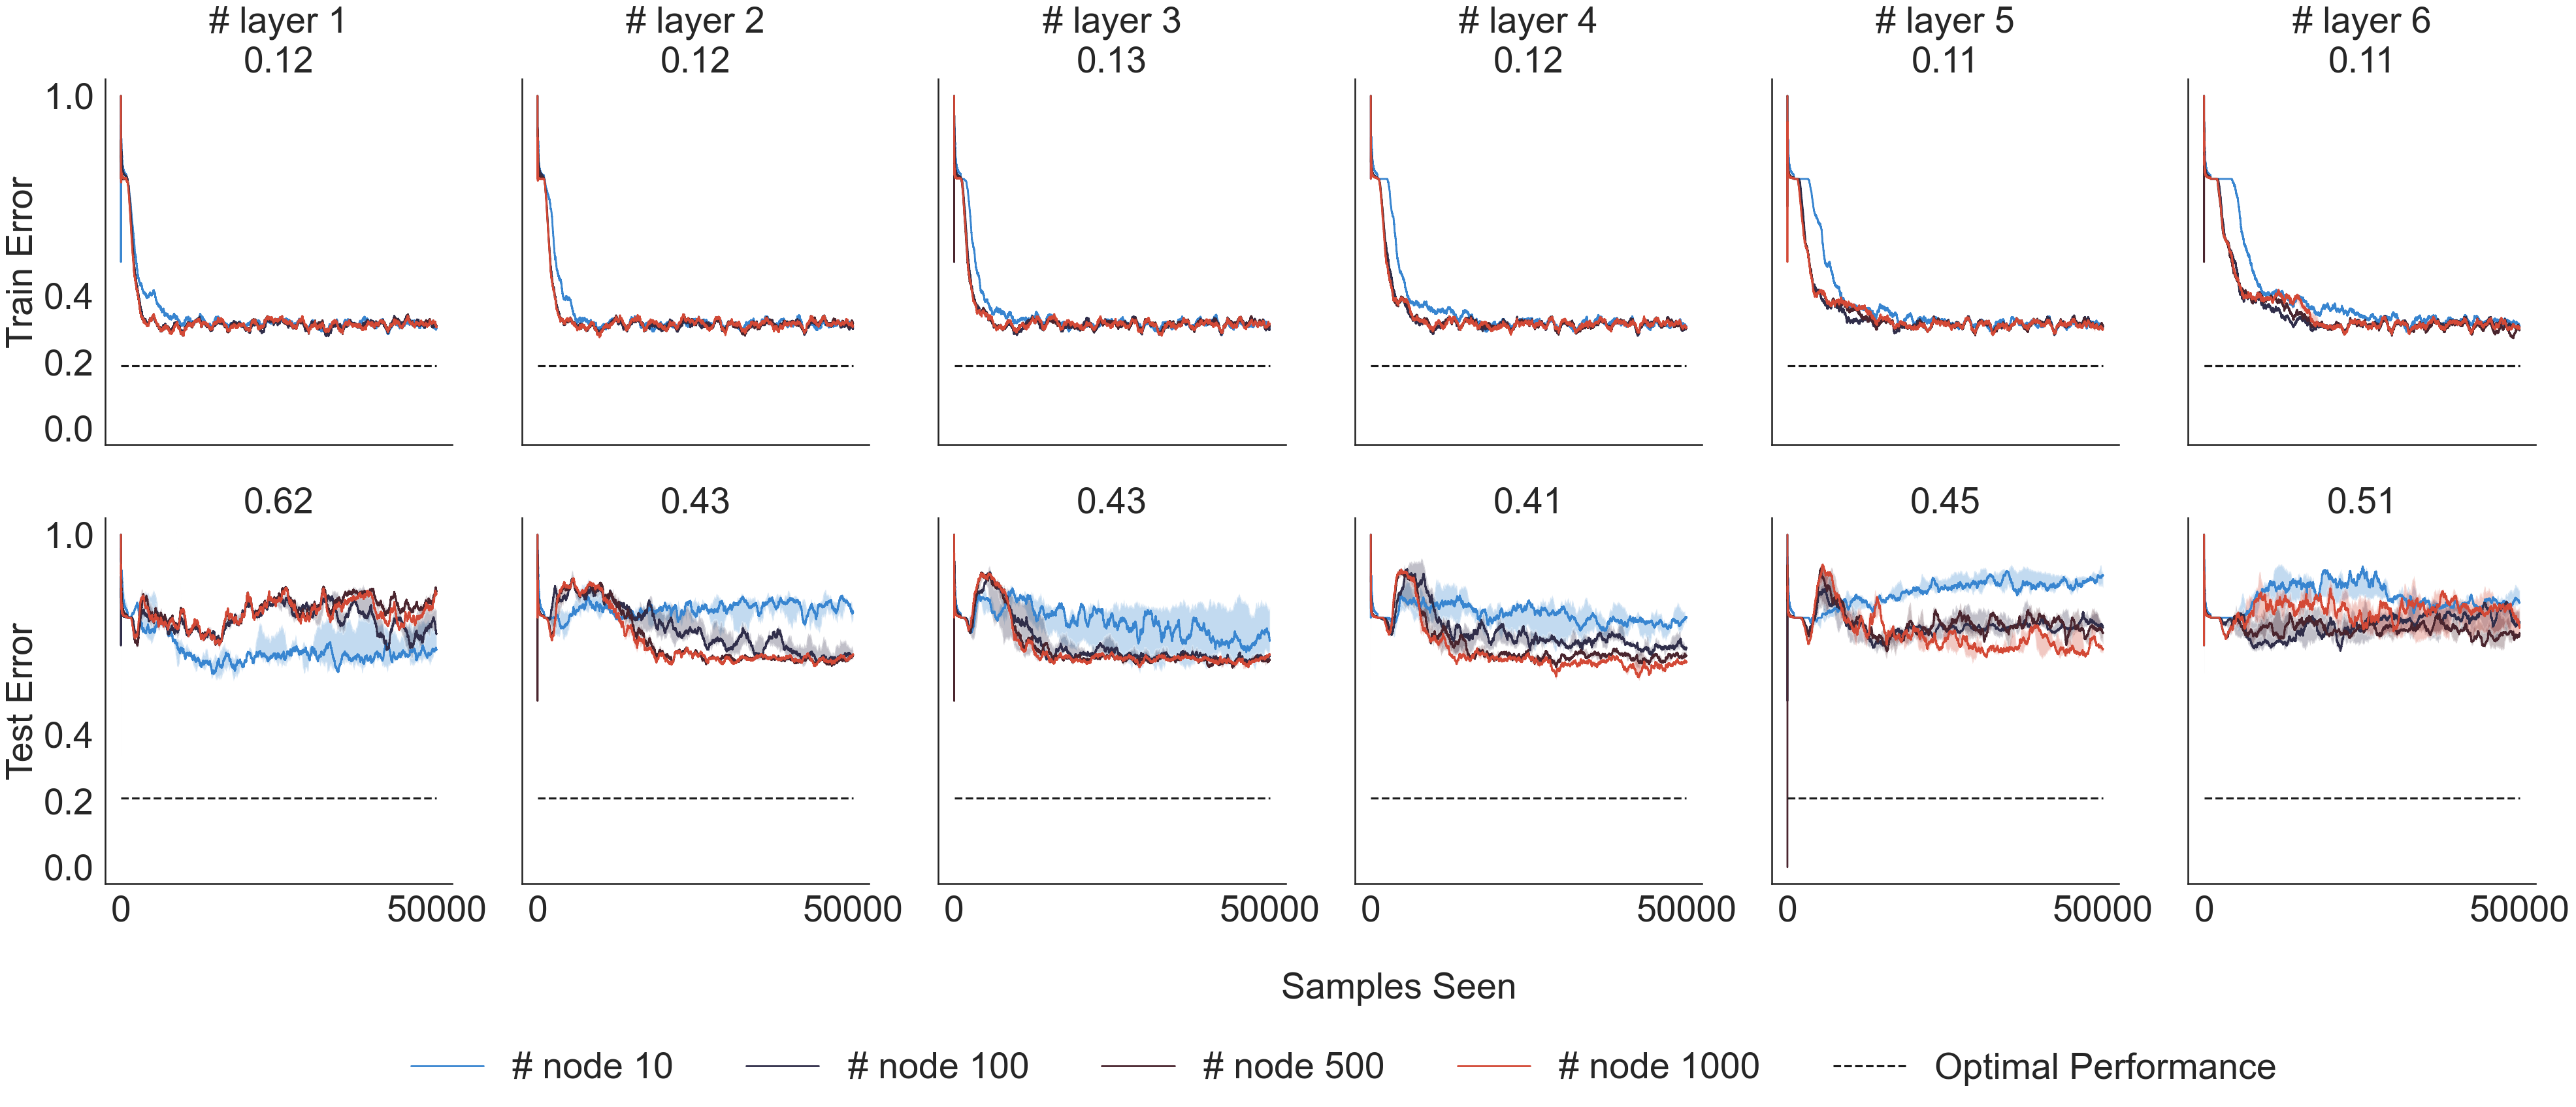

In [21]:
with open('pickle_files/rnn_changing_nodes_layers.pickle', 'rb') as f:
    (result_train, result_test) = pickle.load(f)

fig, ax = plt.subplots(2, 6, figsize=(48,16), sharex=True, sharey=True)
total_samples = 50000
nodes = [10,100,500,1000]
layers = [1,2,3,4,5,6]
reps=5
samples = list(range(1,total_samples-1))

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("icefire", n_colors=len(nodes))
font = 40
# samples_to_show = 10000

for ii, layer in enumerate(layers):
    res_train = []
    res_test = []
    for jj, node in enumerate(nodes):
        if ii == 0:
            ax[0][ii].plot(samples, np.median(1-np.array(result_train[layer][node]),axis=0),linewidth=2, c=clr[jj], label='# node '+str(node))
        else:
            ax[0][ii].plot(samples, np.median(1-np.array(result_train[layer][node]),axis=0),linewidth=2, c=clr[jj])
        
        ax[1][ii].plot(samples, np.median(1-np.array(result_test[layer][node]),axis=0),linewidth=2, c=clr[jj])
        ax[1][ii].fill_between(samples, np.quantile(1-np.array(result_test[layer][node]), 0.25, axis=0), np.quantile(1-np.array(result_test[layer][node]), 0.75, axis=0), facecolor=clr[jj], alpha=.3)


    ax[0][ii].hlines(1-(3.0+1/4.0)/4, 0, total_samples, linestyles='dashed', color='k')        
    ax[0][ii].fill_between(samples, np.quantile(1-np.array(result_train[layer][node]), 0.25, axis=0), np.quantile(1-np.array(result_train[layer][node]), 0.75, axis=0), facecolor=clr[jj], alpha=.3)

    ax[0][ii].tick_params(labelsize=font)

    res = np.round((3.0+1/4.0)/4 - np.median(np.array(result_train[layer][1000]),axis=0)[-1],2)
    ax[0][ii].set_title('# layer '+str(layer)+'\n'+str(res),fontsize=font)

    res = np.round((3.0+1/6.0)/4 - np.median(np.array(result_test[layer][1000]),axis=0)[-1],2)
    ax[1][ii].set_title(str(res),fontsize=font)

    right_side = ax[0][ii].spines["right"]
    right_side.set_visible(False)
    top_side = ax[0][ii].spines["top"]
    top_side.set_visible(False)

    
    ax[1][ii].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')
    ax[1][ii].tick_params(labelsize=40)

    right_side = ax[1][ii].spines["right"]
    right_side.set_visible(False)
    top_side = ax[1][ii].spines["top"]
    top_side.set_visible(False)

ax[0][5].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance', color='k')      
ax[0][0].set_ylabel('Train Error', fontsize=font)
ax[1][0].set_ylabel('Test Error', fontsize=font)
#ax[1][3].set_xlabel('Samples Seen', fontsize=font+20)
ax[0][0].set_yticks([0,.2,.4,1])
ax[0][0].set_xticks([0,50000])

fig.text(0.5,0,'Samples Seen',fontsize=font)
fig.legend(bbox_to_anchor=(0.52, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=5, loc='upper center', fontsize=font, frameon=False)

In [22]:
node = 1000
layer = 6
reps = 5
lr = 4e-4
result_train = {}
result_test = {}

total_samples = 50000
working_memories = [1,2,4,6,8,10]
short_term_memory = 1
n_community = 2
n_members = 3

token_size = n_community*n_members+1

for working_memory in working_memories:
    print("Doing working memory ", working_memory)
    input_size = token_size*working_memory
    
    result_train[working_memory] = []
    result_test[working_memory] = []
    for _ in tqdm(range(reps)):
        train_data = get_sequence(total_samples, n_community, n_members)
        test_data = get_sequence(total_samples, n_community, n_members, train=False)
        model = RNN(input_size, node, num_layers=layer, token_size=token_size)
        _, train_acc, test_acc = wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=lr)
        result_train[working_memory].append(train_acc)
        result_test[working_memory].append(test_acc)

res = (result_train, result_test)

with open('pickle_files/rnn_changing_working_memory.pickle', 'wb') as f:
    pickle.dump(res, f)

#############################################
working_memory = 1
short_term_memories = [1,2,4,6,8,10]
for short_term_memory in short_term_memories:
    print("Doing short term memory ", short_term_memory)
    input_size = token_size*working_memory
    
    result_train[working_memory] = []
    result_test[working_memory] = []
    for _ in tqdm(range(reps)):
        train_data = get_sequence(total_samples, n_community, n_members)
        test_data = get_sequence(total_samples, n_community, n_members, train=False)
        model = RNN(input_size, node, num_layers=layer, token_size=token_size)
        _, train_acc, test_acc = wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=lr)
        result_train[working_memory].append(train_acc)
        result_test[working_memory].append(test_acc)

res = (result_train, result_test)

with open('pickle_files/rnn_changing_short_term_memory.pickle', 'wb') as f:
    pickle.dump(res, f)

Doing working memory  1


100%|██████████| 5/5 [39:06<00:00, 469.23s/it]


Doing working memory  2


100%|██████████| 5/5 [40:50<00:00, 490.04s/it]


Doing working memory  4


...

100%|██████████| 5/5 [2:04:51<00:00, 1498.37s/it]


Doing short term memory  8


100%|██████████| 5/5 [2:29:35<00:00, 1795.14s/it]  


Doing short term memory  10


100%|██████████| 5/5 [3:04:46<00:00, 2217.25s/it]  


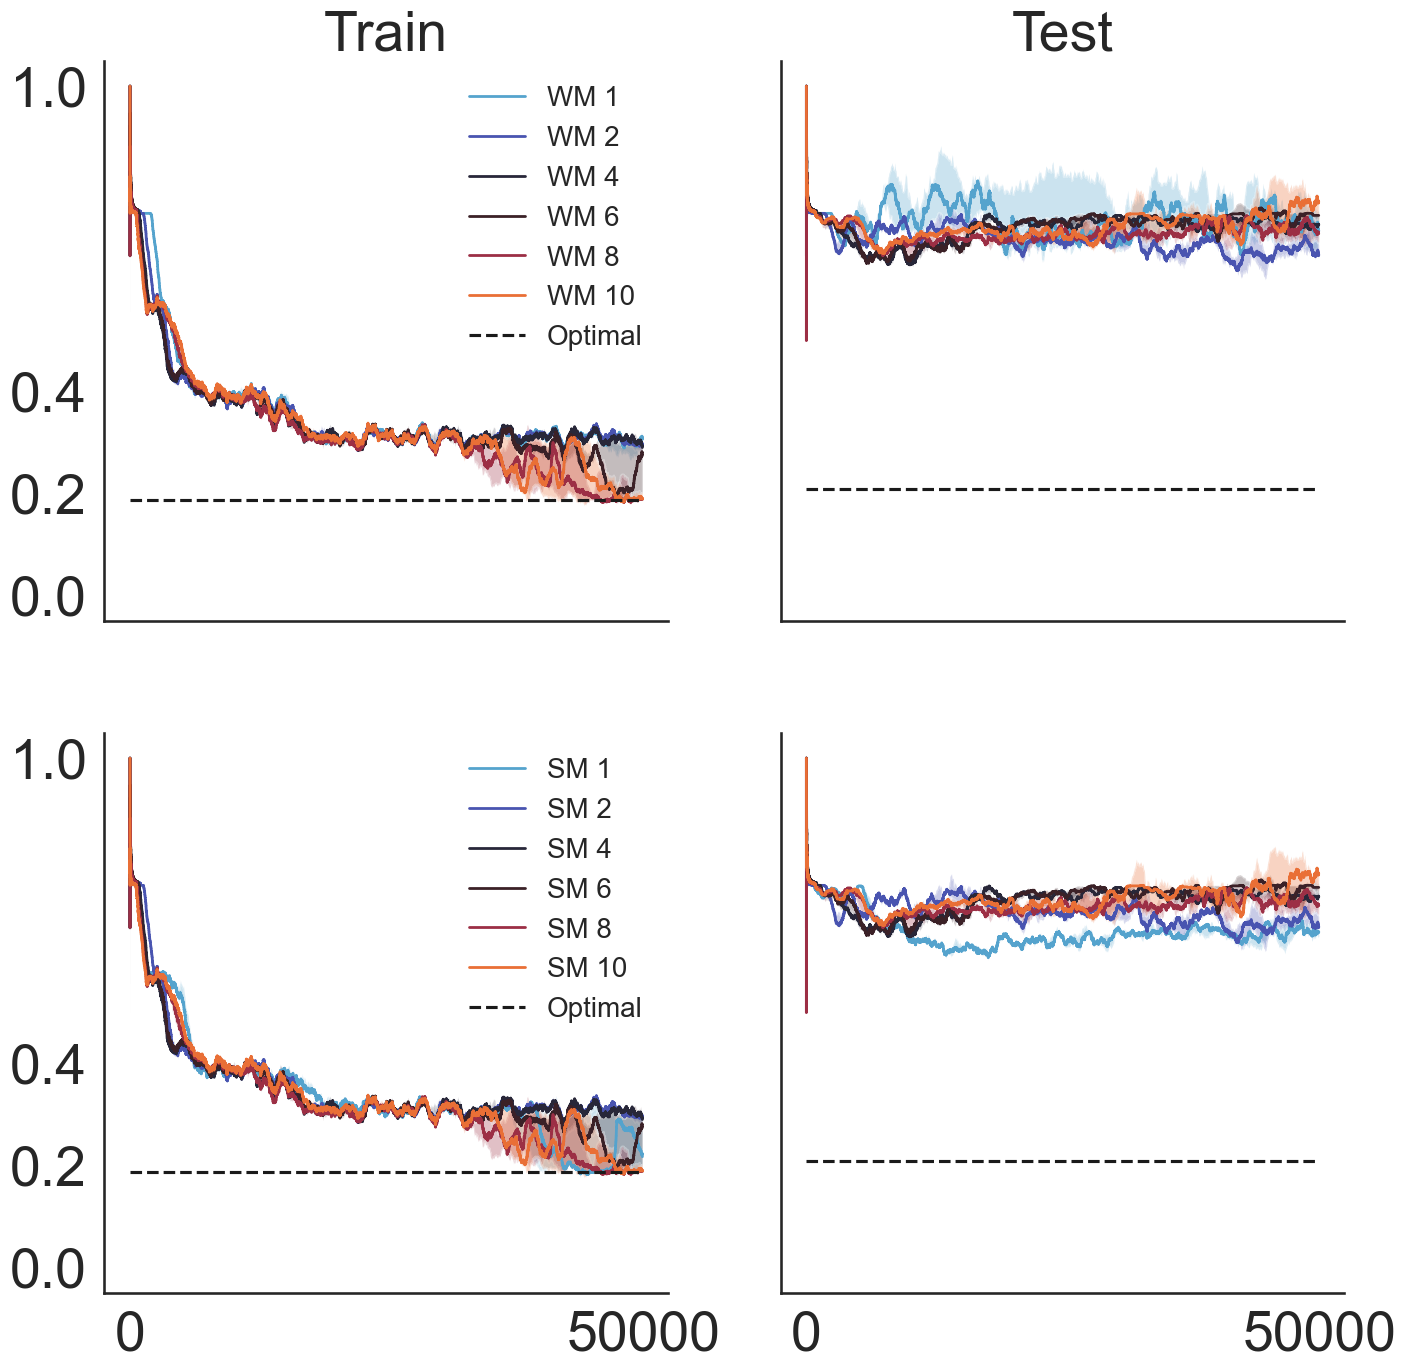

In [25]:
with open('pickle_files/rnn_changing_working_memory.pickle', 'rb') as f:
    (result_train, result_test) = pickle.load(f)

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
fig, ax = plt.subplots(2, 2, figsize=(16,16), sharex=True, sharey=True)
total_samples = 49900
reps=5
working_memories = [1,2,4,6,8,10]
samples = list(range(1,total_samples+1))
clr = sns.color_palette("icefire", n_colors=len(working_memories))

for ii, mem in enumerate(working_memories):
    ax[0][0].plot(samples, np.median(1-np.array(result_train[mem]),axis=0)[:total_samples],linewidth=2, c=clr[ii], label='WM '+str(mem))
    ax[0][0].fill_between(samples, np.quantile(1-np.array(result_train[mem]), 0.25, axis=0)[:total_samples], np.quantile(1-np.array(result_train[mem]), 0.75, axis=0)[:total_samples], facecolor=clr[ii], alpha=.3)

    ax[0][1].plot(samples, np.median(1-np.array(result_test[mem]),axis=0)[:total_samples],linewidth=2, c=clr[ii])
    ax[0][1].fill_between(samples, np.quantile(1-np.array(result_test[mem]), 0.25, axis=0)[:total_samples], np.quantile(1-np.array(result_test[mem]), 0.75, axis=0)[:total_samples], facecolor=clr[ii], alpha=.3)

ax[0][0].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', color='k', label='Optimal')
ax[0][1].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')

ax[0][0].legend(fontsize=20, frameon=False)
ax[0][0].set_title('Train',fontsize=font)
ax[0][1].set_title('Test',fontsize=font)
############################################
with open('pickle_files/rnn_changing_short_term_memory.pickle', 'rb') as f:
    (result_train, result_test) = pickle.load(f)

total_samples = 49900
reps=5
short_term_memories = [1,2,4,6,8,10]
samples = list(range(1,total_samples+1))
clr = sns.color_palette("icefire", n_colors=len(working_memories))

for ii, mem in enumerate(short_term_memories):
    ax[1][0].plot(samples, np.median(1-np.array(result_train[mem]),axis=0)[:total_samples],linewidth=2, c=clr[ii], label='SM '+str(mem))
    ax[1][0].fill_between(samples, np.quantile(1-np.array(result_train[mem]), 0.25, axis=0)[:total_samples], np.quantile(1-np.array(result_train[mem]), 0.75, axis=0)[:total_samples], facecolor=clr[ii], alpha=.3)

    ax[1][1].plot(samples, np.median(1-np.array(result_test[mem]),axis=0)[:total_samples],linewidth=2, c=clr[ii])
    ax[1][1].fill_between(samples, np.quantile(1-np.array(result_test[mem]), 0.25, axis=0)[:total_samples], np.quantile(1-np.array(result_test[mem]), 0.75, axis=0)[:total_samples], facecolor=clr[ii], alpha=.3)

ax[1][0].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', color='k', label='Optimal')
ax[1][1].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')

ax[1][0].legend(fontsize=20, frameon=False)
ax[0][0].set_yticks([0,.2,.4,1])
ax[0][0].set_xticks([0,50000])

for ii in range(2):
    for jj in range(2):
        ax[ii][jj].tick_params(labelsize=40)

        right_side = ax[ii][jj].spines["right"]
        right_side.set_visible(False)
        top_side = ax[ii][jj].spines["top"]
        top_side.set_visible(False)

In [14]:
node = 1000
layer = 2
reps = 5
lr = 4e-4
result_train = {}
result_test = {}

total_samples = 100000
working_memory = 10
short_term_memory = 1
n_communities = [2,10,30,40,50,100,200]
n_members = 3

for n_community in n_communities:
    print("Doing community ", n_community)
    
    token_size = n_community*n_members+1
    input_size = token_size*working_memory

    result_train[n_community] = []
    result_test[n_community] = []
    for _ in tqdm(range(reps)):
        train_data = get_sequence(total_samples, n_community, n_members)
        test_data = get_sequence(total_samples, n_community, n_members, train=False)
        model = RNN(input_size, node, num_layers=layer, token_size=token_size)
        _, train_acc, test_acc = wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=lr)
        result_train[n_community].append(train_acc)
        result_test[n_community].append(test_acc)

res = (result_train, result_test)

with open('pickle_files/rnn_changing_community_number.pickle', 'wb') as f:
    pickle.dump(res, f)

Doing community  2


100%|██████████| 5/5 [26:24<00:00, 316.96s/it]


Doing community  10


100%|██████████| 5/5 [28:17<00:00, 339.60s/it]


Doing community  30


...

100%|██████████| 5/5 [37:39<00:00, 451.80s/it]


Doing community  100


100%|██████████| 5/5 [42:41<00:00, 512.30s/it]


Doing community  200


100%|██████████| 5/5 [57:59<00:00, 695.82s/it]


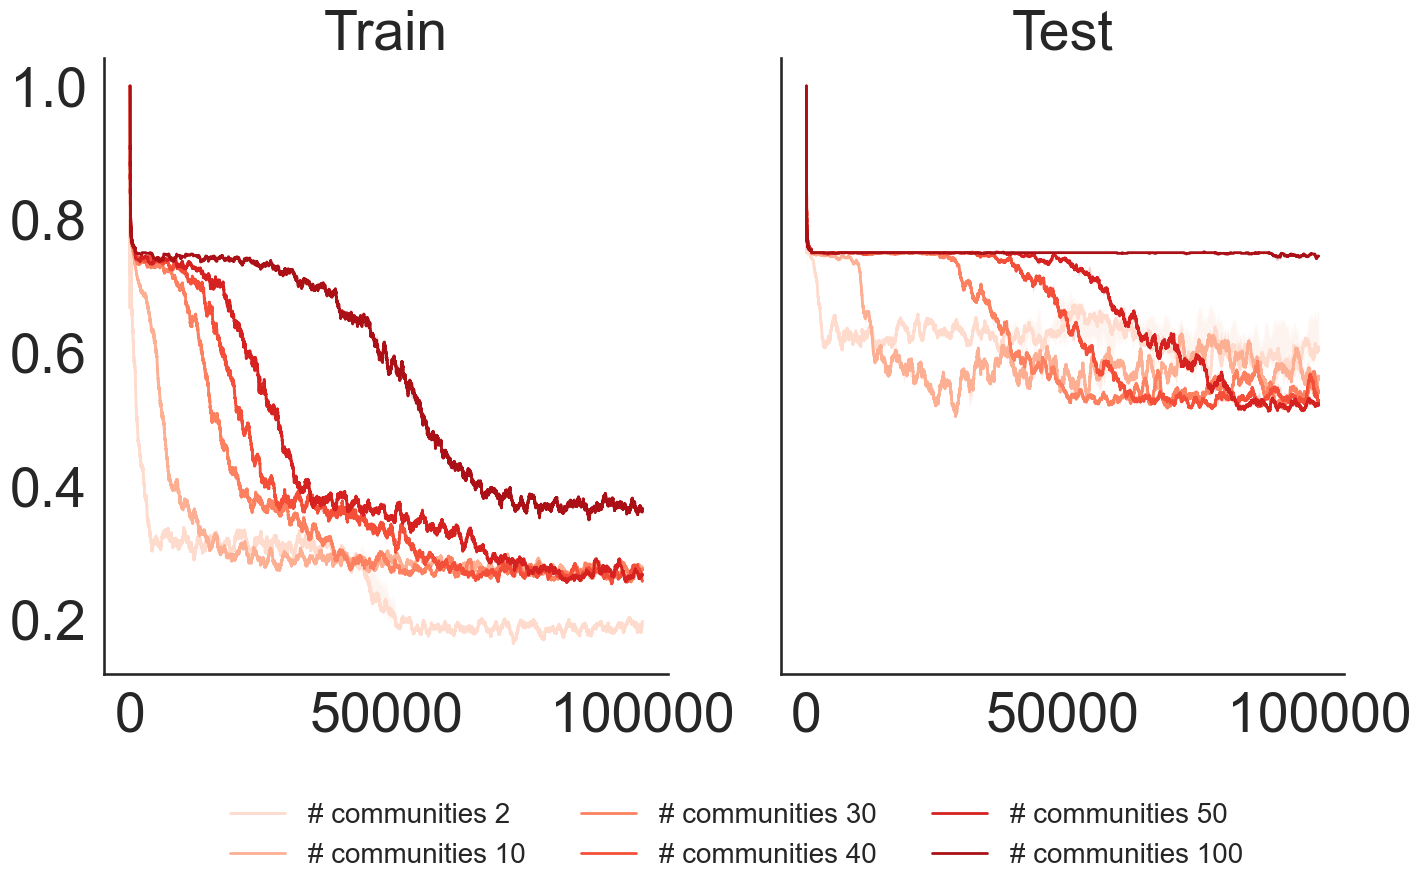

In [27]:
with open('pickle_files/rnn_changing_community_number.pickle', 'rb') as f:
    (result_train, result_test) = pickle.load(f)

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
fig, ax = plt.subplots(1, 2, figsize=(16,8), sharex=True, sharey=True)
total_samples = 99980
reps=5
n_communities = [2,10,30,40,50,100]
samples = list(range(1,total_samples+1))
clr = sns.color_palette("Reds", n_colors=len(n_communities))

for ii, n_community in enumerate(n_communities):
    ax[0].plot(samples, np.median(1-np.array(result_train[n_community]),axis=0)[:total_samples],linewidth=2, c=clr[ii])
    ax[0].fill_between(samples, np.quantile(1-np.array(result_train[n_community]), 0.25, axis=0)[:total_samples], np.quantile(1-np.array(result_train[n_community]), 0.75, axis=0)[:total_samples], facecolor=clr[ii], alpha=.3)

    ax[1].plot(samples, np.median(1-np.array(result_test[n_community]),axis=0)[:total_samples],linewidth=2, c=clr[ii], label='# communities '+str(n_community))
    ax[1].fill_between(samples, np.quantile(1-np.array(result_test[n_community]), 0.25, axis=0)[:total_samples], np.quantile(1-np.array(result_test[n_community]), 0.75, axis=0)[:total_samples], facecolor=clr[ii], alpha=.3)

# ax[0].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', color='k')
# ax[1].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k', label='Optimal')

fig.legend(bbox_to_anchor=(0.52, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=3, loc='upper center', fontsize=20, frameon=False)
ax[0].set_title('Train',fontsize=font)
ax[1].set_title('Test',fontsize=font)

for ii in range(2):
    ax[ii].tick_params(labelsize=40)

    right_side = ax[ii].spines["right"]
    right_side.set_visible(False)
    top_side = ax[ii].spines["top"]
    top_side.set_visible(False)